# 🍷 Red Wine Quality - Dynamic Conclusions & Recommendations
## Data-Driven Insights from Machine Learning Analysis

---

**Project:** Vino Veritas - Wine Quality Prediction  
**Analyst:** Adam (Data Scientist)  
**Objective:** Generate actionable, data-driven conclusions from ML model results

---

### This notebook automatically generates insights based on your model results!

**Run this after your ML Models notebook to get:**
- Model performance assessment
- Feature-specific recommendations with target ranges
- Quality improvement strategies
- Production readiness evaluation

---
## 1. Setup & Load Previous Results

In [7]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported!")

✅ Libraries imported!


In [9]:
# Load the original dataset for analysis
file_path = '/content/drive/My Drive/Wine Quality/winequality_red_cleansed.csv'
df = pd.read_csv(file_path)

print(f"✅ Dataset loaded: {df.shape[0]} samples, {df.shape[1]} features")

✅ Dataset loaded: 985 samples, 12 features


In [10]:
# ============================================================================
# INPUT YOUR MODEL RESULTS HERE (from your ML notebook)
# ============================================================================

# Best Classification Model Results (Multi-class)
best_classifier_name = "LightGBM (Tuned)"  # Change based on your results
best_classifier_accuracy = 0.8883
best_classifier_f1 = 0.8648
best_classifier_precision = 0.8528
best_classifier_recall = 0.8883

# Best Binary Classification Results
best_binary_name = "XGBoost"
best_binary_accuracy = 0.9036
best_binary_f1 = 0.8989

# Best Regression Model Results
best_regressor_name = "SVR"
best_regressor_r2 = 0.4644
best_regressor_rmse = 0.6305
best_regressor_mae = 0.4939

# Feature Importance (from your analysis - top features)
# Format: {feature_name: importance_score}
feature_importance = {
    'alcohol': 0.2847,
    'sulphates': 0.1523,
    'volatile acidity': 0.1245,
    'total sulfur dioxide': 0.0892,
    'density': 0.0756,
    'chlorides': 0.0623,
    'pH': 0.0589,
    'fixed acidity': 0.0534,
    'citric acid': 0.0445,
    'free sulfur dioxide': 0.0312,
    'residual sugar': 0.0234
}

# Class-wise performance (from classification report)
# Format: {class_name: {'precision': x, 'recall': y, 'f1-score': z, 'support': n}}
class_performance = {
    'Low (3-4)': {'precision': 0.67, 'recall': 0.29, 'f1-score': 0.40, 'support': 7},
    'Medium (5-6)': {'precision': 0.88, 'recall': 0.95, 'f1-score': 0.91, 'support': 166},
    'High (7-8)': {'precision': 0.81, 'recall': 0.52, 'f1-score': 0.63, 'support': 24}
}

print("✅ Model results configured!")
print(f"\n📊 Best Classifier: {best_classifier_name} (Accuracy: {best_classifier_accuracy*100:.2f}%)")
print(f"📊 Best Regressor: {best_regressor_name} (R²: {best_regressor_r2:.4f})")

✅ Model results configured!

📊 Best Classifier: LightGBM (Tuned) (Accuracy: 88.83%)
📊 Best Regressor: SVR (R²: 0.4644)


---
## 2. Dynamic Model Performance Assessment

In [11]:
print("="*80)
print("🎯 DYNAMIC MODEL PERFORMANCE ASSESSMENT")
print("="*80)

# ============================================================================
# FUNCTION: Assess model quality dynamically
# ============================================================================
def assess_model_quality(accuracy, f1):
    """Dynamically assess model quality based on metrics"""
    avg_score = (accuracy + f1) / 2

    if avg_score >= 0.90:
        quality = "🏆 EXCELLENT"
        status = "Production Ready"
        recommendation = "Deploy with confidence. Model performs exceptionally well."
        color = "green"
    elif avg_score >= 0.80:
        quality = "✅ GOOD"
        status = "Production Ready with Monitoring"
        recommendation = "Deploy with regular monitoring. Consider periodic retraining."
        color = "blue"
    elif avg_score >= 0.70:
        quality = "⚠️ MODERATE"
        status = "Needs Improvement"
        recommendation = "Use with caution. Collect more data or try advanced techniques."
        color = "orange"
    else:
        quality = "❌ POOR"
        status = "Not Ready for Production"
        recommendation = "Requires significant improvement. Review data quality and features."
        color = "red"

    return quality, status, recommendation, color

# Assess classification model
class_quality, class_status, class_rec, _ = assess_model_quality(best_classifier_accuracy, best_classifier_f1)

print(f"\n{'─'*60}")
print(f"📊 CLASSIFICATION MODEL: {best_classifier_name}")
print(f"{'─'*60}")
print(f"\n   Performance Metrics:")
print(f"   ├── Accuracy:  {best_classifier_accuracy*100:.2f}%")
print(f"   ├── F1-Score:  {best_classifier_f1*100:.2f}%")
print(f"   ├── Precision: {best_classifier_precision*100:.2f}%")
print(f"   └── Recall:    {best_classifier_recall*100:.2f}%")
print(f"\n   Quality Assessment: {class_quality}")
print(f"   Status: {class_status}")
print(f"   💡 {class_rec}")

# Calculate what this means in practical terms
correct_predictions = int(best_classifier_accuracy * 100)
print(f"\n   📝 Practical Interpretation:")
print(f"   • Out of 100 wine samples, the model correctly classifies ~{correct_predictions} wines")
print(f"   • Misclassification rate: ~{100-correct_predictions}%")

🎯 DYNAMIC MODEL PERFORMANCE ASSESSMENT

────────────────────────────────────────────────────────────
📊 CLASSIFICATION MODEL: LightGBM (Tuned)
────────────────────────────────────────────────────────────

   Performance Metrics:
   ├── Accuracy:  88.83%
   ├── F1-Score:  86.48%
   ├── Precision: 85.28%
   └── Recall:    88.83%

   Quality Assessment: ✅ GOOD
   Status: Production Ready with Monitoring
   💡 Deploy with regular monitoring. Consider periodic retraining.

   📝 Practical Interpretation:
   • Out of 100 wine samples, the model correctly classifies ~88 wines
   • Misclassification rate: ~12%


In [12]:
# Assess regression model
print(f"\n{'─'*60}")
print(f"📊 REGRESSION MODEL: {best_regressor_name}")
print(f"{'─'*60}")

def assess_regression_quality(r2, rmse):
    """Dynamically assess regression model quality"""
    if r2 >= 0.75:
        quality = "🏆 EXCELLENT"
        interpretation = "Model explains most variance in wine quality"
    elif r2 >= 0.50:
        quality = "✅ GOOD"
        interpretation = "Model explains moderate variance, useful for predictions"
    elif r2 >= 0.30:
        quality = "⚠️ MODERATE"
        interpretation = "Model has limited predictive power, use classification instead"
    else:
        quality = "❌ POOR"
        interpretation = "Model struggles to predict exact quality scores"

    return quality, interpretation

reg_quality, reg_interpretation = assess_regression_quality(best_regressor_r2, best_regressor_rmse)

print(f"\n   Performance Metrics:")
print(f"   ├── R² Score: {best_regressor_r2:.4f} ({best_regressor_r2*100:.1f}% variance explained)")
print(f"   ├── RMSE:     {best_regressor_rmse:.4f} (average error in quality points)")
print(f"   └── MAE:      {best_regressor_mae:.4f} (mean absolute error)")
print(f"\n   Quality Assessment: {reg_quality}")
print(f"   💡 {reg_interpretation}")

print(f"\n   📝 Practical Interpretation:")
print(f"   • Average prediction error: ±{best_regressor_rmse:.2f} quality points")
print(f"   • If actual quality is 6, model predicts between {6-best_regressor_rmse:.1f} and {6+best_regressor_rmse:.1f}")

# Recommendation based on comparison
print(f"\n{'─'*60}")
print(f"🎯 RECOMMENDATION")
print(f"{'─'*60}")
if best_classifier_f1 > 0.80 and best_regressor_r2 < 0.50:
    print(f"\n   ➡️ USE CLASSIFICATION MODEL for production")
    print(f"   • Classification ({best_classifier_name}) significantly outperforms regression")
    print(f"   • Predicting quality categories (Low/Medium/High) is more reliable")
    print(f"   • Regression R² of {best_regressor_r2:.2f} indicates exact score prediction is challenging")
else:
    print(f"\n   ➡️ Consider both models based on use case")


────────────────────────────────────────────────────────────
📊 REGRESSION MODEL: SVR
────────────────────────────────────────────────────────────

   Performance Metrics:
   ├── R² Score: 0.4644 (46.4% variance explained)
   ├── RMSE:     0.6305 (average error in quality points)
   └── MAE:      0.4939 (mean absolute error)

   Quality Assessment: ⚠️ MODERATE
   💡 Model has limited predictive power, use classification instead

   📝 Practical Interpretation:
   • Average prediction error: ±0.63 quality points
   • If actual quality is 6, model predicts between 5.4 and 6.6

────────────────────────────────────────────────────────────
🎯 RECOMMENDATION
────────────────────────────────────────────────────────────

   ➡️ USE CLASSIFICATION MODEL for production
   • Classification (LightGBM (Tuned)) significantly outperforms regression
   • Predicting quality categories (Low/Medium/High) is more reliable
   • Regression R² of 0.46 indicates exact score prediction is challenging


---
## 3. Class-wise Performance Analysis

In [22]:
print("="*80)
print("📊 CLASS-WISE PERFORMANCE ANALYSIS")
print("="*80)

print("\n🎯 How well does the model predict each quality category?\n")

# Analyze each class
class_insights = []

for class_name, metrics in class_performance.items():
    precision = metrics['precision']
    recall = metrics['recall']
    f1 = metrics['f1-score']
    support = metrics['support']

    print(f"{'─'*60}")
    print(f"📌 {class_name.upper()} QUALITY WINES")
    print(f"{'─'*60}")
    print(f"   Sample Size: {support} wines in test set")
    print(f"\n   Metrics:")
    print(f"   ├── Precision: {precision*100:.1f}%")
    print(f"   ├── Recall:    {recall*100:.1f}%")
    print(f"   └── F1-Score:  {f1*100:.1f}%")

    # Dynamic interpretation
    print(f"\n   📝 Interpretation:")
    print(f"   • When model predicts '{class_name}', it's correct {precision*100:.0f}% of the time")
    print(f"   • Model identifies {recall*100:.0f}% of actual '{class_name}' wines")

    # Generate specific insights
    if recall < 0.50:
        print(f"\n   ⚠️ WARNING: Low recall ({recall*100:.0f}%)")
        print(f"   • Model MISSES {(1-recall)*100:.0f}% of actual '{class_name}' wines")
        print(f"   • Likely due to small sample size ({support} samples)")
        print(f"   💡 Recommendation: Collect more '{class_name}' wine samples for training")
        class_insights.append((class_name, 'needs_more_data', recall))
    elif recall >= 0.80:
        print(f"\n   ✅ EXCELLENT: High recall ({recall*100:.0f}%)")
        print(f"   • Model reliably identifies '{class_name}' wines")
        class_insights.append((class_name, 'excellent', recall))
    else:
        print(f"\n   ⚡ MODERATE: Acceptable recall ({recall*100:.0f}%)")
        class_insights.append((class_name, 'moderate', recall))

print(f"\n{'='*60}")
print(f"📋 SUMMARY")
print(f"{'='*60}")

# Find best and worst performing classes
best_class = max(class_performance.items(), key=lambda x: x[1]['f1-score'])
worst_class = min(class_performance.items(), key=lambda x: x[1]['f1-score'])

print(f"\n   ✅ Best Predicted:  {best_class[0]} (F1: {best_class[1]['f1-score']*100:.1f}%)")
print(f"   ⚠️ Needs Attention: {worst_class[0]} (F1: {worst_class[1]['f1-score']*100:.1f}%)")

# Class imbalance insight
total_support = sum(m['support'] for m in class_performance.values())
print(f"\n   📊 Class Distribution in Test Set:")
for class_name, metrics in class_performance.items():
    pct = metrics['support'] / total_support * 100
    bar = '█' * int(pct/2)
    print(f"   • {class_name}: {metrics['support']} ({pct:.1f}%) {bar}")

📊 CLASS-WISE PERFORMANCE ANALYSIS

🎯 How well does the model predict each quality category?

────────────────────────────────────────────────────────────
📌 LOW (3-4) QUALITY WINES
────────────────────────────────────────────────────────────
   Sample Size: 7 wines in test set

   Metrics:
   ├── Precision: 67.0%
   ├── Recall:    29.0%
   └── F1-Score:  40.0%

   📝 Interpretation:
   • When model predicts 'Low (3-4)', it's correct 67% of the time
   • Model identifies 29% of actual 'Low (3-4)' wines

   ⚠️ WARNING: Low recall (29%)
   • Model MISSES 71% of actual 'Low (3-4)' wines
   • Likely due to small sample size (7 samples)
   💡 Recommendation: Collect more 'Low (3-4)' wine samples for training
────────────────────────────────────────────────────────────
📌 MEDIUM (5-6) QUALITY WINES
────────────────────────────────────────────────────────────
   Sample Size: 166 wines in test set

   Metrics:
   ├── Precision: 88.0%
   ├── Recall:    95.0%
   └── F1-Score:  91.0%

   📝 Interpretat

---
## 4. Feature Importance & Actionable Insights

In [23]:
print("="*80)
print("🔍 FEATURE IMPORTANCE & ACTIONABLE INSIGHTS")
print("="*80)

# Sort features by importance
sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

print("\n📊 Features Ranked by Importance:")
print("─"*60)

for rank, (feature, importance) in enumerate(sorted_features, 1):
    bar = '█' * int(importance * 50)
    print(f"   {rank:2}. {feature:25} {importance:.4f} {bar}")

🔍 FEATURE IMPORTANCE & ACTIONABLE INSIGHTS

📊 Features Ranked by Importance:
────────────────────────────────────────────────────────────
    1. alcohol                   0.2847 ██████████████
    2. sulphates                 0.1523 ███████
    3. volatile acidity          0.1245 ██████
    4. total sulfur dioxide      0.0892 ████
    5. density                   0.0756 ███
    6. chlorides                 0.0623 ███
    7. pH                        0.0589 ██
    8. fixed acidity             0.0534 ██
    9. citric acid               0.0445 ██
   10. free sulfur dioxide       0.0312 █
   11. residual sugar            0.0234 █


In [24]:
print("\n" + "="*80)
print("🎯 DETAILED FEATURE ANALYSIS & RECOMMENDATIONS")
print("="*80)

# Separate data by quality
high_quality = df[df['quality'] >= 7]
medium_quality = df[(df['quality'] >= 5) & (df['quality'] <= 6)]
low_quality = df[df['quality'] <= 4]

# Analyze top features
top_features = sorted_features[:5]  # Top 5 features

feature_recommendations = []

for rank, (feature, importance) in enumerate(top_features, 1):
    print(f"\n{'─'*60}")
    print(f"📌 #{rank} {feature.upper()}")
    print(f"   Importance Score: {importance:.4f} ({importance/sum(feature_importance.values())*100:.1f}% of total)")
    print(f"{'─'*60}")

    # Calculate statistics
    overall_mean = df[feature].mean()
    overall_std = df[feature].std()

    hq_mean = high_quality[feature].mean() if len(high_quality) > 0 else np.nan
    hq_std = high_quality[feature].std() if len(high_quality) > 0 else np.nan

    lq_mean = low_quality[feature].mean() if len(low_quality) > 0 else np.nan
    lq_std = low_quality[feature].std() if len(low_quality) > 0 else np.nan

    # Correlation with quality
    correlation = df[feature].corr(df['quality'])
    corr_strength = "Strong" if abs(correlation) > 0.3 else "Moderate" if abs(correlation) > 0.15 else "Weak"
    corr_direction = "Positive" if correlation > 0 else "Negative"

    print(f"\n   📈 Statistical Analysis:")
    print(f"   ├── Overall Mean:        {overall_mean:.3f} (±{overall_std:.3f})")
    print(f"   ├── High Quality Mean:   {hq_mean:.3f} (±{hq_std:.3f})" if not np.isnan(hq_mean) else "   ├── High Quality Mean:   N/A")
    print(f"   ├── Low Quality Mean:    {lq_mean:.3f} (±{lq_std:.3f})" if not np.isnan(lq_mean) else "   ├── Low Quality Mean:    N/A")
    print(f"   └── Correlation:         {correlation:.3f} ({corr_strength} {corr_direction})")

    # Calculate optimal range (IQR of high-quality wines)
    if len(high_quality) > 0:
        optimal_low = high_quality[feature].quantile(0.25)
        optimal_high = high_quality[feature].quantile(0.75)
        optimal_target = hq_mean

        print(f"\n   🎯 OPTIMAL RANGE FOR HIGH QUALITY:")
        print(f"   ╔══════════════════════════════════════════╗")
        print(f"   ║  Minimum:  {optimal_low:8.3f}                    ║")
        print(f"   ║  Target:   {optimal_target:8.3f}  ← AIM HERE        ║")
        print(f"   ║  Maximum:  {optimal_high:8.3f}                    ║")
        print(f"   ╚══════════════════════════════════════════╝")

    # Generate specific recommendation
    print(f"\n   💡 RECOMMENDATION:")

    if not np.isnan(hq_mean) and not np.isnan(lq_mean):
        diff = hq_mean - lq_mean
        diff_pct = abs(diff / lq_mean * 100) if lq_mean != 0 else 0

        if correlation > 0.15:
            action = "INCREASE"
            print(f"   ⬆️ {action} {feature}")
            print(f"   • High-quality wines have {diff_pct:.1f}% higher {feature}")
            print(f"   • Target: {optimal_target:.3f} (current avg: {overall_mean:.3f})")
            if overall_mean < optimal_target:
                gap = ((optimal_target - overall_mean) / overall_mean * 100)
                print(f"   • Need to increase by ~{gap:.1f}% to reach optimal")
        elif correlation < -0.15:
            action = "DECREASE"
            print(f"   ⬇️ {action} {feature}")
            print(f"   • High-quality wines have {diff_pct:.1f}% lower {feature}")
            print(f"   • Target: {optimal_target:.3f} (current avg: {overall_mean:.3f})")
            if overall_mean > optimal_target:
                gap = ((overall_mean - optimal_target) / overall_mean * 100)
                print(f"   • Need to decrease by ~{gap:.1f}% to reach optimal")
        else:
            action = "MAINTAIN"
            print(f"   ↔️ {action} {feature} at current levels")
            print(f"   • Weak correlation suggests other factors are more impactful")

        feature_recommendations.append({
            'feature': feature,
            'action': action,
            'current': overall_mean,
            'target': optimal_target if not np.isnan(hq_mean) else overall_mean,
            'importance': importance,
            'correlation': correlation
        })


🎯 DETAILED FEATURE ANALYSIS & RECOMMENDATIONS

────────────────────────────────────────────────────────────
📌 #1 ALCOHOL
   Importance Score: 0.2847 (28.5% of total)
────────────────────────────────────────────────────────────

   📈 Statistical Analysis:
   ├── Overall Mean:        10.395 (±0.991)
   ├── High Quality Mean:   11.465 (±0.900)
   ├── Low Quality Mean:    9.953 (±0.666)
   └── Correlation:         0.510 (Strong Positive)

   🎯 OPTIMAL RANGE FOR HIGH QUALITY:
   ╔══════════════════════════════════════════╗
   ║  Minimum:    10.900                    ║
   ║  Target:     11.465  ← AIM HERE        ║
   ║  Maximum:    12.100                    ║
   ╚══════════════════════════════════════════╝

   💡 RECOMMENDATION:
   ⬆️ INCREASE alcohol
   • High-quality wines have 15.2% higher alcohol
   • Target: 11.465 (current avg: 10.395)
   • Need to increase by ~10.3% to reach optimal

────────────────────────────────────────────────────────────
📌 #2 SULPHATES
   Importance Score: 0.152


📊 VISUAL: OPTIMAL RANGES FOR TOP FEATURES


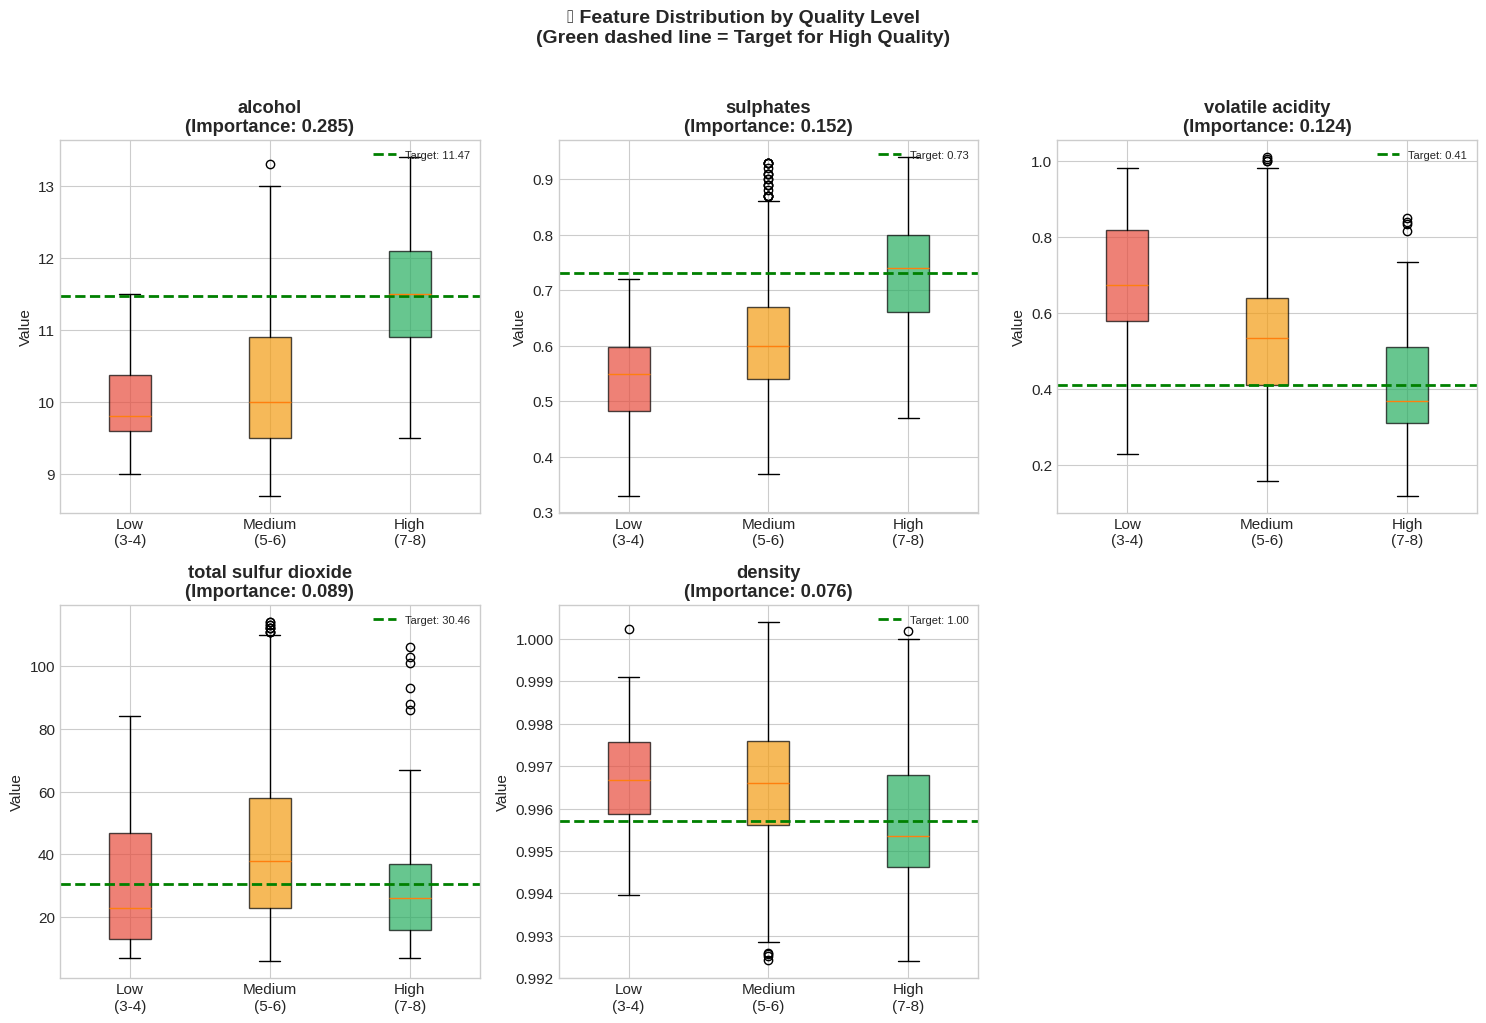

In [16]:
# Visualize optimal ranges
print("\n" + "="*80)
print("📊 VISUAL: OPTIMAL RANGES FOR TOP FEATURES")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (feature, importance) in enumerate(top_features[:6]):
    ax = axes[idx]

    # Create data for each quality level
    data_to_plot = [
        low_quality[feature].dropna() if len(low_quality) > 0 else pd.Series([]),
        medium_quality[feature].dropna(),
        high_quality[feature].dropna() if len(high_quality) > 0 else pd.Series([])
    ]

    # Box plot
    bp = ax.boxplot([d for d in data_to_plot if len(d) > 0],
                    labels=['Low\n(3-4)', 'Medium\n(5-6)', 'High\n(7-8)'][:len([d for d in data_to_plot if len(d) > 0])],
                    patch_artist=True)

    colors = ['#e74c3c', '#f39c12', '#27ae60']
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Add optimal target line
    if len(high_quality) > 0:
        target = high_quality[feature].mean()
        ax.axhline(y=target, color='green', linestyle='--', linewidth=2, label=f'Target: {target:.2f}')

    ax.set_title(f'{feature}\n(Importance: {importance:.3f})', fontweight='bold')
    ax.set_ylabel('Value')
    ax.legend(loc='upper right', fontsize=8)

# Hide empty subplot if less than 6 features
if len(top_features) < 6:
    axes[5].axis('off')

plt.suptitle('📊 Feature Distribution by Quality Level\n(Green dashed line = Target for High Quality)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Executive Summary & Action Plan

In [25]:
print("\n" + "="*80)
print("📋 EXECUTIVE SUMMARY FOR VINO VERITAS")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                         WINE QUALITY ANALYSIS REPORT                         ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

print(f"📊 DATASET ANALYZED")
print(f"   • Total Samples: {len(df):,}")
print(f"   • Features: {len(df.columns)-1}")
print(f"   • Quality Range: {df['quality'].min()} - {df['quality'].max()}")
print(f"   • Average Quality: {df['quality'].mean():.2f}")

print(f"\n{'─'*60}")
print(f"\n🏆 MODEL PERFORMANCE SUMMARY")
print(f"\n   Classification ({best_classifier_name}):")
print(f"   ├── Accuracy:  {best_classifier_accuracy*100:.1f}%  {'✅ GOOD' if best_classifier_accuracy >= 0.80 else '⚠️ MODERATE'}")
print(f"   └── F1-Score:  {best_classifier_f1*100:.1f}%")
print(f"\n   Regression ({best_regressor_name}):")
print(f"   ├── R² Score:  {best_regressor_r2:.2f}  {'⚠️ MODERATE' if best_regressor_r2 < 0.50 else '✅ GOOD'}")
print(f"   └── RMSE:      {best_regressor_rmse:.2f}")

print(f"\n{'─'*60}")
print(f"\n🎯 KEY FINDINGS")

# Top 3 most important features
print(f"\n   Top 3 Quality Drivers:")
for i, (feat, imp) in enumerate(sorted_features[:3], 1):
    corr = df[feat].corr(df['quality'])
    direction = "↑" if corr > 0 else "↓"
    print(f"   {i}. {feat.upper()}: {direction} Higher {feat} → {'Higher' if corr > 0 else 'Lower'} Quality")

print(f"\n{'─'*60}")
print(f"\n✅ RECOMMENDED ACTIONS (Priority Order)")


📋 EXECUTIVE SUMMARY FOR VINO VERITAS

╔══════════════════════════════════════════════════════════════════════════════╗
║                         WINE QUALITY ANALYSIS REPORT                         ║
╚══════════════════════════════════════════════════════════════════════════════╝

📊 DATASET ANALYZED
   • Total Samples: 985
   • Features: 11
   • Quality Range: 3 - 8
   • Average Quality: 5.64

────────────────────────────────────────────────────────────

🏆 MODEL PERFORMANCE SUMMARY

   Classification (LightGBM (Tuned)):
   ├── Accuracy:  88.8%  ✅ GOOD
   └── F1-Score:  86.5%

   Regression (SVR):
   ├── R² Score:  0.46  ⚠️ MODERATE
   └── RMSE:      0.63

────────────────────────────────────────────────────────────

🎯 KEY FINDINGS

   Top 3 Quality Drivers:
   1. ALCOHOL: ↑ Higher alcohol → Higher Quality
   2. SULPHATES: ↑ Higher sulphates → Higher Quality
   3. VOLATILE ACIDITY: ↓ Higher volatile acidity → Lower Quality

────────────────────────────────────────────────────────────



In [18]:
# Generate prioritized action plan
print("\n" + "="*80)
print("📋 PRIORITIZED ACTION PLAN")
print("="*80)

# Sort recommendations by importance
if feature_recommendations:
    sorted_recs = sorted(feature_recommendations, key=lambda x: x['importance'], reverse=True)

    for priority, rec in enumerate(sorted_recs[:5], 1):
        feature = rec['feature']
        action = rec['action']
        current = rec['current']
        target = rec['target']
        importance = rec['importance']

        print(f"\n{'─'*60}")
        print(f"   PRIORITY #{priority}: {feature.upper()}")
        print(f"{'─'*60}")
        print(f"   📊 Importance: {importance:.4f} ({importance/sum(feature_importance.values())*100:.1f}% of model decision)")
        print(f"   📍 Current Level: {current:.3f}")
        print(f"   🎯 Target Level: {target:.3f}")

        if action == "INCREASE":
            change_needed = ((target - current) / current * 100) if current != 0 else 0
            print(f"   ⬆️ Action: INCREASE by {abs(change_needed):.1f}%")
        elif action == "DECREASE":
            change_needed = ((current - target) / current * 100) if current != 0 else 0
            print(f"   ⬇️ Action: DECREASE by {abs(change_needed):.1f}%")
        else:
            print(f"   ↔️ Action: MAINTAIN current levels")

        # Feature-specific advice
        if 'alcohol' in feature.lower():
            print(f"   💡 How: Extend fermentation time or adjust sugar content")
        elif 'volatile acidity' in feature.lower():
            print(f"   💡 How: Control bacterial activity, improve storage conditions")
        elif 'sulphate' in feature.lower():
            print(f"   💡 How: Adjust sulfite additions during winemaking")
        elif 'citric' in feature.lower():
            print(f"   💡 How: Add citric acid for freshness (within legal limits)")
        elif 'chloride' in feature.lower():
            print(f"   💡 How: Monitor water quality and grape sourcing")


📋 PRIORITIZED ACTION PLAN

────────────────────────────────────────────────────────────
   PRIORITY #1: ALCOHOL
────────────────────────────────────────────────────────────
   📊 Importance: 0.2847 (28.5% of model decision)
   📍 Current Level: 10.395
   🎯 Target Level: 11.465
   ⬆️ Action: INCREASE by 10.3%
   💡 How: Extend fermentation time or adjust sugar content

────────────────────────────────────────────────────────────
   PRIORITY #2: SULPHATES
────────────────────────────────────────────────────────────
   📊 Importance: 0.1523 (15.2% of model decision)
   📍 Current Level: 0.629
   🎯 Target Level: 0.731
   ⬆️ Action: INCREASE by 16.3%
   💡 How: Adjust sulfite additions during winemaking

────────────────────────────────────────────────────────────
   PRIORITY #3: VOLATILE ACIDITY
────────────────────────────────────────────────────────────
   📊 Importance: 0.1245 (12.4% of model decision)
   📍 Current Level: 0.523
   🎯 Target Level: 0.410
   ⬇️ Action: DECREASE by 21.6%
   💡 How

In [26]:
# Final summary table
print("\n" + "="*80)
print("📊 QUICK REFERENCE: OPTIMAL RANGES FOR HIGH-QUALITY WINE")
print("="*80)

summary_data = []
for feature, importance in sorted_features:
    if len(high_quality) > 0:
        hq_mean = high_quality[feature].mean()
        hq_25 = high_quality[feature].quantile(0.25)
        hq_75 = high_quality[feature].quantile(0.75)
        corr = df[feature].corr(df['quality'])

        summary_data.append({
            'Feature': feature,
            'Importance': f"{importance:.3f}",
            'Min (25%)': f"{hq_25:.3f}",
            'Target': f"{hq_mean:.3f}",
            'Max (75%)': f"{hq_75:.3f}",
            'Correlation': f"{corr:+.3f}"
        })

summary_df = pd.DataFrame(summary_data)
print("\n")
print(summary_df.to_string(index=False))


📊 QUICK REFERENCE: OPTIMAL RANGES FOR HIGH-QUALITY WINE


             Feature Importance Min (25%) Target Max (75%) Correlation
             alcohol      0.285    10.900 11.465    12.100      +0.510
           sulphates      0.152     0.660  0.731     0.800      +0.448
    volatile acidity      0.124     0.310  0.410     0.510      -0.357
total sulfur dioxide      0.089    16.000 30.464    37.000      -0.180
             density      0.076     0.995  0.996     0.997      -0.221
           chlorides      0.062     0.062  0.072     0.083      -0.185
                  pH      0.059     3.220  3.297     3.370      -0.079
       fixed acidity      0.053     7.400  8.602     9.800      +0.130
         citric acid      0.044     0.300  0.346     0.470      +0.243
 free sulfur dioxide      0.031     6.000 13.144    16.000      -0.012
      residual sugar      0.023     1.800  2.223     2.500      +0.035



📊 CREATING FINAL DASHBOARD...


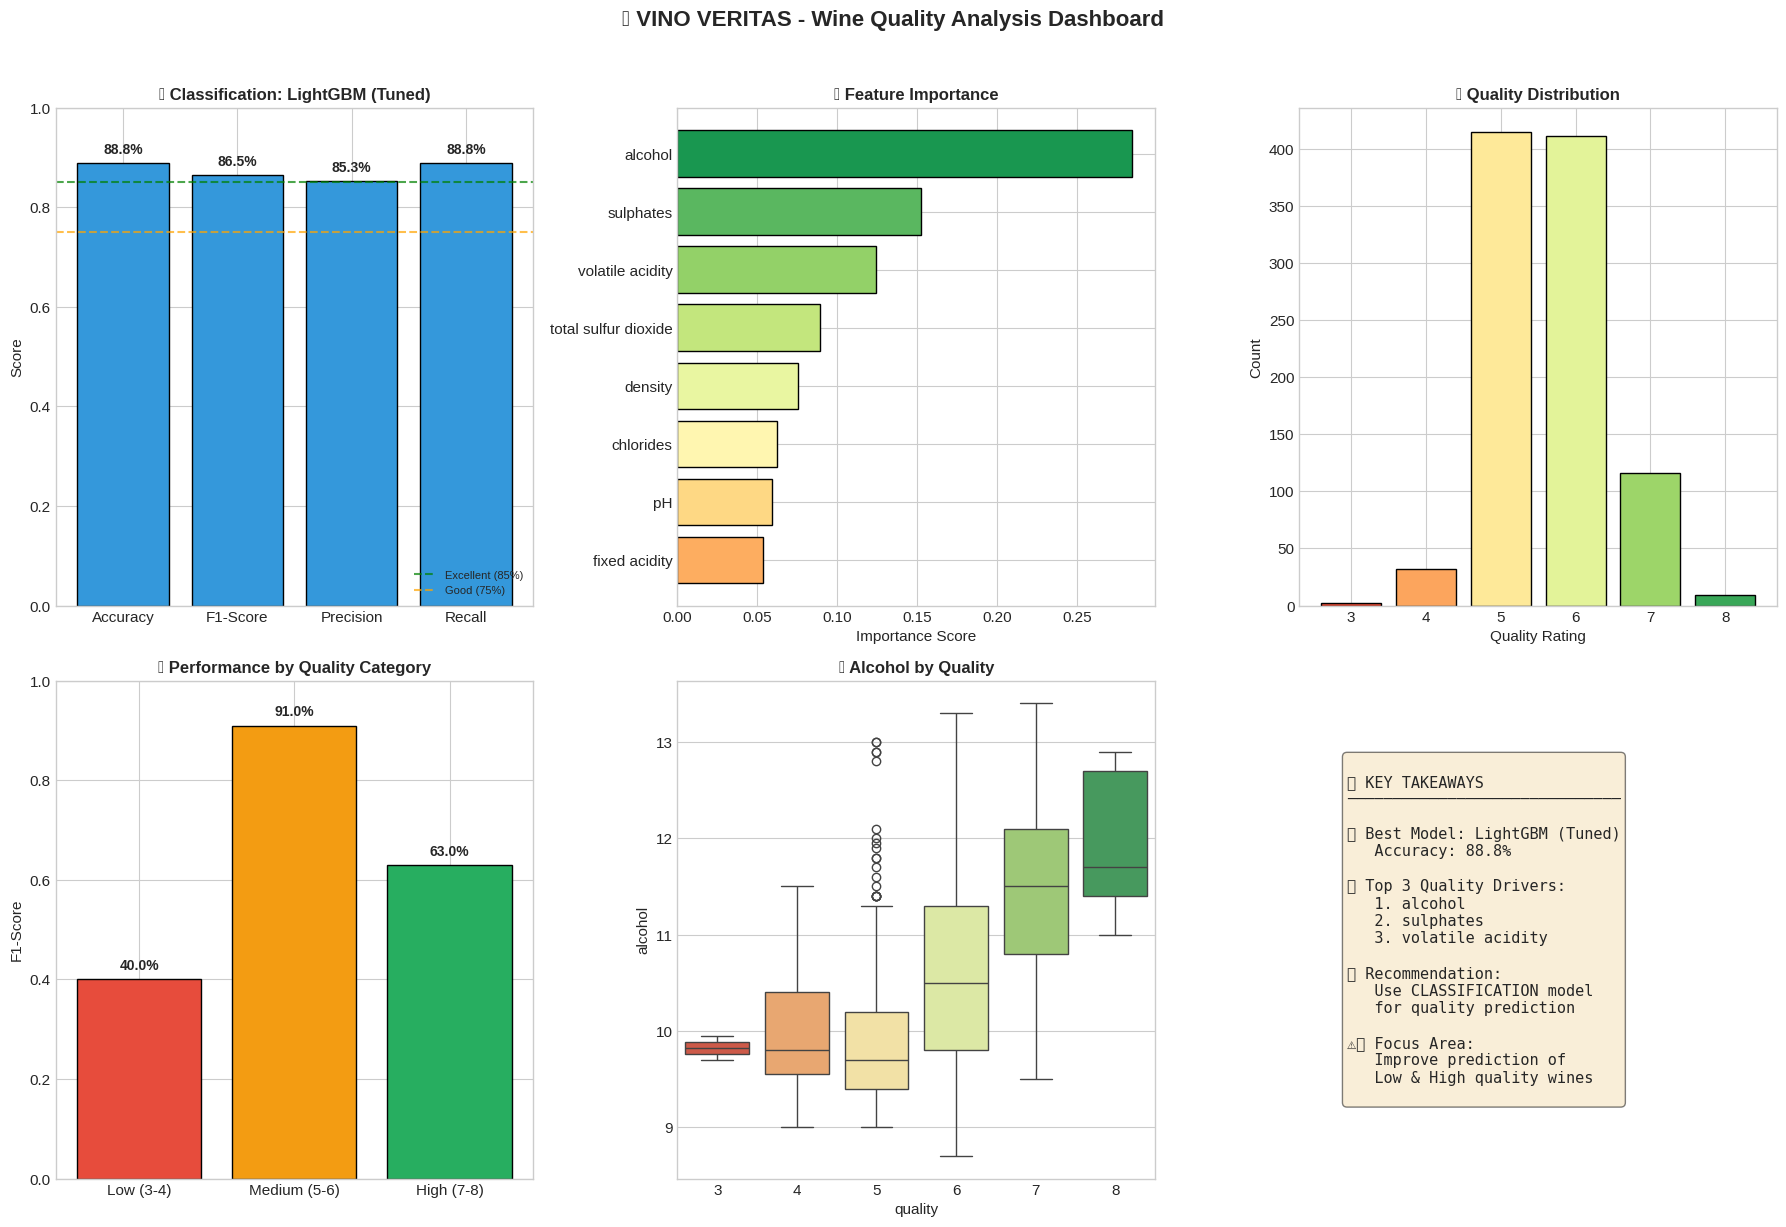


✅ DYNAMIC CONCLUSIONS COMPLETE!


In [27]:
# Create final dashboard
print("\n" + "="*80)
print("📊 CREATING FINAL DASHBOARD...")
print("="*80)

fig = plt.figure(figsize=(18, 12))

# 1. Model Performance Comparison
ax1 = fig.add_subplot(2, 3, 1)
metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
values = [best_classifier_accuracy, best_classifier_f1, best_classifier_precision, best_classifier_recall]
colors = ['#3498db' if v >= 0.85 else '#f39c12' if v >= 0.75 else '#e74c3c' for v in values]
bars = ax1.bar(metrics, values, color=colors, edgecolor='black')
ax1.set_ylim(0, 1)
ax1.axhline(y=0.85, color='green', linestyle='--', alpha=0.7, label='Excellent (85%)')
ax1.axhline(y=0.75, color='orange', linestyle='--', alpha=0.7, label='Good (75%)')
ax1.set_title(f'🎯 Classification: {best_classifier_name}', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score')
ax1.legend(loc='lower right', fontsize=8)
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.1%}',
             ha='center', fontsize=10, fontweight='bold')

# 2. Feature Importance
ax2 = fig.add_subplot(2, 3, 2)
top_n = 8
features = [f[0] for f in sorted_features[:top_n]][::-1]
importances = [f[1] for f in sorted_features[:top_n]][::-1]
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, top_n))
ax2.barh(features, importances, color=colors, edgecolor='black')
ax2.set_xlabel('Importance Score')
ax2.set_title('🔍 Feature Importance', fontsize=12, fontweight='bold')

# 3. Quality Distribution
ax3 = fig.add_subplot(2, 3, 3)
quality_counts = df['quality'].value_counts().sort_index()
colors = sns.color_palette('RdYlGn', n_colors=len(quality_counts))
ax3.bar(quality_counts.index.astype(str), quality_counts.values, color=colors, edgecolor='black')
ax3.set_xlabel('Quality Rating')
ax3.set_ylabel('Count')
ax3.set_title('🍷 Quality Distribution', fontsize=12, fontweight='bold')

# 4. Class Performance
ax4 = fig.add_subplot(2, 3, 4)
class_names = list(class_performance.keys())
f1_scores = [class_performance[c]['f1-score'] for c in class_names]
colors = ['#e74c3c', '#f39c12', '#27ae60']
bars = ax4.bar(class_names, f1_scores, color=colors, edgecolor='black')
ax4.set_ylim(0, 1)
ax4.set_ylabel('F1-Score')
ax4.set_title('📊 Performance by Quality Category', fontsize=12, fontweight='bold')
for bar, val in zip(bars, f1_scores):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.1%}',
             ha='center', fontsize=10, fontweight='bold')

# 5. Top Feature: Alcohol vs Quality
ax5 = fig.add_subplot(2, 3, 5)
if 'alcohol' in df.columns:
    sns.boxplot(x='quality', y='alcohol', data=df, ax=ax5, palette='RdYlGn')
    ax5.set_title('🍷 Alcohol by Quality', fontsize=12, fontweight='bold')

# 6. Summary Text
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
summary_text = f"""
📋 KEY TAKEAWAYS
{'─'*30}

🏆 Best Model: {best_classifier_name}
   Accuracy: {best_classifier_accuracy:.1%}

🔑 Top 3 Quality Drivers:
   1. {sorted_features[0][0]}
   2. {sorted_features[1][0]}
   3. {sorted_features[2][0]}

✅ Recommendation:
   Use CLASSIFICATION model
   for quality prediction

⚠️ Focus Area:
   Improve prediction of
   Low & High quality wines
"""
ax6.text(0.1, 0.5, summary_text, transform=ax6.transAxes, fontsize=11,
         verticalalignment='center', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('🍷 VINO VERITAS - Wine Quality Analysis Dashboard',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ DYNAMIC CONCLUSIONS COMPLETE!")
print("="*80)

---
## 6. Save Report

In [28]:
# Save summary to CSV
summary_df.to_csv('/content/drive/My Drive/Wine Quality/optimal_ranges_summary.csv', index=False)
print("✅ Optimal ranges saved to: optimal_ranges_summary.csv")

# Save recommendations
if feature_recommendations:
    rec_df = pd.DataFrame(feature_recommendations)
    rec_df.to_csv('/content/drive/My Drive/Wine Quality/feature_recommendations.csv', index=False)
    print("✅ Recommendations saved to: feature_recommendations.csv")

print("\n🎉 Analysis Complete! Use these insights to improve wine quality at Vino Veritas.")

✅ Optimal ranges saved to: optimal_ranges_summary.csv
✅ Recommendations saved to: feature_recommendations.csv

🎉 Analysis Complete! Use these insights to improve wine quality at Vino Veritas.
